# L9.5 — LLMOps Boss: a 30-day dashboard

Hands-on notebook for the lesson [`9-5-ops-boss.mdx`](../../llm-quest-theory/level-9/9-5-ops-boss.mdx).

> **Learning objectives**
> - Combine **all five Level 9 skills** into a single SRE-style dashboard for an LLM product: observability (9-1), cost/latency (9-2), prompt versioning (9-3), privacy (9-4), and a unified alert engine.
> - Simulate 30 days of traffic across three prompt versions (including a silently-regressing canary) and surface the regression from the log alone.
> - Produce a **one-screen executive summary** (CEO question: "how much did we spend, how is quality, any bugs?") that answers in numbers.
> - Show an end-to-end **incident response**: detect the regression, roll back to a known-good version, verify metrics recover.

## Connection to the theory
The source `.mdx` sketches a Grafana + Alertmanager + Loki stack. We reproduce all the *analysis* pieces with pandas + matplotlib on an in-notebook SQLite log. Wire them up to real agents in production by replacing the generator with the OpenTelemetry exporter.

In [1]:
# ---- Setup ----
import os, re, json, random, sqlite3, hashlib, time, pathlib
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. The database schema
One SQLite table — the same shape as your production `requests` table in Postgres / ClickHouse. Everything (dashboard, alerts, roll-ups) is derived from this one source of truth.

In [2]:
conn = sqlite3.connect(":memory:")
conn.executescript("""
CREATE TABLE requests (
    ts                REAL NOT NULL,
    request_id        TEXT NOT NULL PRIMARY KEY,
    user_id           TEXT NOT NULL,
    model             TEXT NOT NULL,
    prompt_version    TEXT NOT NULL,
    feature           TEXT NOT NULL,
    input_tokens      INTEGER NOT NULL,
    output_tokens     INTEGER NOT NULL,
    latency_ms        INTEGER NOT NULL,
    cost_usd          REAL NOT NULL,
    cache_hit         INTEGER NOT NULL,
    error             TEXT,
    feedback          INTEGER,
    faithfulness      REAL
);
CREATE INDEX idx_ts        ON requests(ts);
CREATE INDEX idx_user      ON requests(user_id);
CREATE INDEX idx_prompt    ON requests(prompt_version);

CREATE TABLE audit (
    ts       REAL NOT NULL,
    actor    TEXT,
    action   TEXT NOT NULL,
    detail   TEXT
);
""")
conn.commit()
print("schema ready")

schema ready


## 2. Generate 30 days of realistic traffic
- 3 features: `chat`, `rag`, `agent`
- 3 models: `mini` (cheap/fast), `haiku`, `opus` (expensive/slow)
- 3 prompt versions: `v1` (mature), `v2` (candidate), `v3` (canary — silently regresses faithfulness at 70%)
- Diurnal traffic with a weekly cycle, a minor cost spike on day 14, and a **quality regression on v3**.

In [3]:
PRICE = {
    "mini":   (0.15 / 1_000_000, 0.60 / 1_000_000),
    "haiku":  (1.00 / 1_000_000, 5.00 / 1_000_000),
    "opus":   (15.0 / 1_000_000, 75.0 / 1_000_000),
}
BASE_LAT = {"mini": 200, "haiku": 280, "opus": 800}

FEATURES       = ["chat", "rag", "agent"]
FEATURE_WEIGHT = [0.50, 0.40, 0.10]
MODELS         = list(PRICE)
MODEL_WEIGHT   = [0.70, 0.25, 0.05]

PROMPT_VERSIONS = ["v1", "v2", "v3"]
# v3 is a canary rolled out at 20% of traffic from day 10 onward; before day 10 only v1/v2 are live.

USERS = [f"u{i:04d}" for i in range(1500)]

START = datetime(2026, 3, 22)        # 30-day window
N_DAYS = 30
rng = random.Random(SEED)

def synth_row(day_idx, hour):
    dt = START + timedelta(days=day_idx, hours=hour, minutes=rng.randint(0, 59), seconds=rng.randint(0, 59))
    ts = dt.timestamp()
    feature = rng.choices(FEATURES, weights=FEATURE_WEIGHT)[0]
    model   = rng.choices(MODELS,   weights=MODEL_WEIGHT)[0]
    # Prompt-version routing
    if day_idx < 10:
        version = rng.choices(["v1", "v2"], weights=[0.80, 0.20])[0]
    else:
        version = rng.choices(["v1", "v2", "v3"], weights=[0.50, 0.30, 0.20])[0]
    cache_hit = rng.random() < 0.30 if feature == "chat" else rng.random() < 0.10
    if cache_hit:
        in_tok, out_tok, lat = 0, 0, int(5 + rng.random() * 10)
        cost = 0.0
    else:
        in_tok  = max(50, int(rng.gauss(500, 120)))
        out_tok = max(10, int(rng.gauss(90, 25)))
        base = BASE_LAT[model]
        lat  = max(40, int(base + rng.gauss(0, base * 0.3)))
        cost = in_tok * PRICE[model][0] + out_tok * PRICE[model][1]
    # Error model: 1.5% baseline, opus spikes on day 14 to simulate an incident
    p_err = 0.015
    if model == "opus" and day_idx == 14: p_err = 0.15
    error = None
    if rng.random() < p_err and not cache_hit:
        error = rng.choice(["rate_limit", "timeout", "server_error"])
        lat = int(lat * 1.8)
    # Quality: feedback + faithfulness (proxy LLM-judge score)
    faith = None
    feedback = None
    if error is None and not cache_hit:
        base_faith = {"v1": 0.90, "v2": 0.90, "v3": 0.70}[version]
        # Small gaussian jitter, clip to [0, 1]
        faith = float(min(1.0, max(0.0, rng.gauss(base_faith, 0.05))))
        p_thumbs_up = 0.9 if faith > 0.8 else 0.55
        feedback = +1 if rng.random() < p_thumbs_up else -1
    return (ts, f"r_{uuid_short()}", rng.choice(USERS), model, version,
            feature, in_tok, out_tok, lat, cost, int(cache_hit), error, feedback, faith)

def uuid_short():
    return hashlib.sha1(str(rng.random()).encode()).hexdigest()[:10]

# Populate
rows = []
for day in range(N_DAYS):
    weekday_mult = 1.0 if START.weekday() in (5, 6) else 1.3     # weekend quieter
    for hour in range(24):
        # Diurnal peak around 14:00
        peak = 1.0 + 0.8 * np.exp(-((hour - 14) ** 2) / 25)
        n = int(rng.gauss(60, 12) * peak * weekday_mult)
        for _ in range(max(1, n)):
            rows.append(synth_row(day, hour))

conn.executemany(
    "INSERT OR IGNORE INTO requests VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)", rows
)
conn.commit()
N = conn.execute("SELECT COUNT(*) FROM requests").fetchone()[0]
print(f"inserted {N:,} rows over {N_DAYS} days")

inserted 55,463 rows over 30 days


## 3. Pandas view for analysis
Pull the table into a DataFrame once; all panels read from it.

In [4]:
df = pd.read_sql("SELECT * FROM requests", conn)
df["datetime"] = pd.to_datetime(df["ts"], unit="s")
df["date"]     = df["datetime"].dt.date
print(df.shape)
print(df.head(2).to_string())

(55463, 16)
             ts    request_id user_id  model prompt_version feature  input_tokens  output_tokens  latency_ms  cost_usd  cache_hit error  feedback  faithfulness            datetime        date
0  1.774113e+09  r_46aefc3d01   u1330  haiku             v1    chat           479            112         325  0.001039          0  None       1.0      0.911615 2026-03-21 17:17:15  2026-03-21
1  1.774115e+09  r_854e72979d   u0778   mini             v1    chat           639             90         164  0.000150          0  None       1.0      0.893934 2026-03-21 17:44:34  2026-03-21


## 4. Executive summary — the CEO's three questions

In [5]:
def ceo_report(df):
    total_cost = df["cost_usd"].sum()
    requests   = len(df)
    dau = df.groupby("date")["user_id"].nunique().mean()
    mau = df["user_id"].nunique()
    err_rate = df["error"].notna().mean()
    p95_lat  = df["latency_ms"].quantile(0.95)
    faith    = df["faithfulness"].dropna().mean()
    thumbs_up_rate = df["feedback"].dropna().eq(1).mean()
    return {
        "requests_total":  requests,
        "cost_total_usd":  round(total_cost, 4),
        "cost_per_req":    round(total_cost / max(requests, 1), 6),
        "MAU":             mau,
        "avg_DAU":         round(dau, 1),
        "error_rate":      round(err_rate, 4),
        "latency_p95_ms":  int(p95_lat),
        "avg_faithfulness":round(faith, 3),
        "thumbs_up_rate":  round(thumbs_up_rate, 3),
    }

for k, v in ceo_report(df).items():
    print(f"  {k:<22}  {v}")

  requests_total          55463
  cost_total_usd          45.6534
  cost_per_req            0.000823
  MAU                     1500
  avg_DAU                 1036.1
  error_rate              0.0125
  latency_p95_ms          430
  avg_faithfulness        0.873
  thumbs_up_rate          0.851


## 5. Full dashboard — six panels

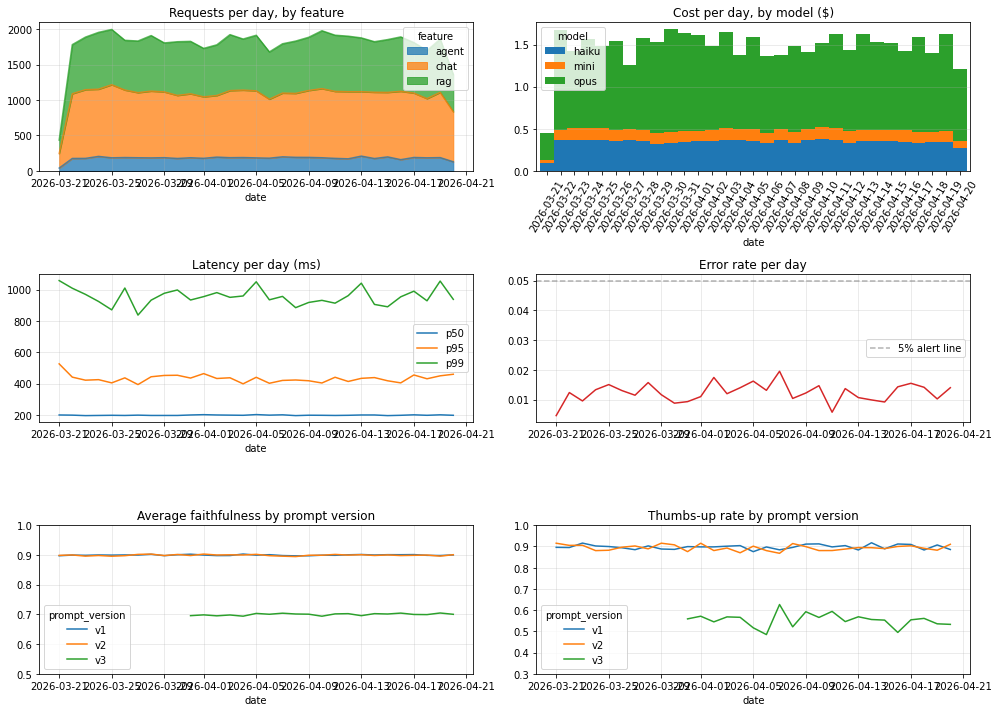

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Panel 1: daily requests by feature
daily = df.groupby(["date", "feature"]).size().unstack(fill_value=0)
daily.plot(ax=axes[0, 0], kind="area", stacked=True, alpha=0.75)
axes[0, 0].set_title("Requests per day, by feature"); axes[0, 0].grid(alpha=0.3)

# Panel 2: daily cost by model
cost_by_model = df.groupby(["date", "model"])["cost_usd"].sum().unstack(fill_value=0)
cost_by_model.plot(ax=axes[0, 1], kind="bar", stacked=True, width=1.0)
axes[0, 1].set_title("Cost per day, by model ($)"); axes[0, 1].tick_params(axis='x', rotation=60)
axes[0, 1].grid(alpha=0.3, axis='y')

# Panel 3: latency p50 / p95 / p99 per day
lat_day = df.groupby("date")["latency_ms"].agg([("p50", lambda s: s.quantile(0.50)),
                                                ("p95", lambda s: s.quantile(0.95)),
                                                ("p99", lambda s: s.quantile(0.99))])
lat_day.plot(ax=axes[1, 0]); axes[1, 0].set_title("Latency per day (ms)"); axes[1, 0].grid(alpha=0.3)

# Panel 4: error rate per day, highlight the spike
err = df.assign(err=df.error.notna()).groupby("date")["err"].mean()
axes[1, 1].plot(err.index, err.values, color="tab:red")
axes[1, 1].axhline(0.05, color="gray", linestyle="--", alpha=0.6, label="5% alert line")
axes[1, 1].set_title("Error rate per day"); axes[1, 1].grid(alpha=0.3); axes[1, 1].legend()

# Panel 5: faithfulness per day per prompt version
faith = df.dropna(subset=["faithfulness"]).groupby(["date", "prompt_version"])["faithfulness"].mean().unstack(fill_value=np.nan)
faith.plot(ax=axes[2, 0]); axes[2, 0].set_title("Average faithfulness by prompt version")
axes[2, 0].grid(alpha=0.3); axes[2, 0].set_ylim(0.5, 1.0)

# Panel 6: thumbs up rate per day per version
fb = df.dropna(subset=["feedback"])
tp = fb.assign(up=(fb.feedback == 1)).groupby(["date", "prompt_version"])["up"].mean().unstack(fill_value=np.nan)
tp.plot(ax=axes[2, 1]); axes[2, 1].set_title("Thumbs-up rate by prompt version")
axes[2, 1].grid(alpha=0.3); axes[2, 1].set_ylim(0.3, 1.0)

plt.tight_layout(); plt.show()

## 6. Alert engine — detect the regression without being told
The engine aggregates yesterday's numbers and fires rules. In production this runs every few minutes; here we sample the most recent 24h window.

In [7]:
def alert_engine(df, window=pd.Timedelta("24h")):
    now = df["datetime"].max()
    recent = df[df["datetime"] >= now - window]
    fired = []

    # Error rate spike
    err = recent["error"].notna().mean()
    if err > 0.05:
        fired.append(("CRITICAL", "error_rate_high", f"{err:.1%}"))

    # Cost/hour projection
    cost24 = recent["cost_usd"].sum()
    baseline_cost = df.groupby(df["datetime"].dt.date)["cost_usd"].sum().mean()
    if cost24 > 1.8 * baseline_cost:
        fired.append(("WARNING", "cost_spike",
                      f"last-24h=${cost24:.2f} vs baseline=${baseline_cost:.2f}"))

    # p95 latency
    p95 = recent["latency_ms"].quantile(0.95)
    if p95 > 3500:
        fired.append(("CRITICAL", "latency_p95_high", f"{int(p95)} ms"))
    elif p95 > 2000:
        fired.append(("WARNING", "latency_p95_elevated", f"{int(p95)} ms"))

    # Per-version quality regression: compare each version's score to the best
    # current-live version, and also flag absolute low scores.
    all_fb = df.dropna(subset=["faithfulness"])
    per_v  = all_fb.groupby("prompt_version")["faithfulness"].mean()
    if len(per_v) > 1:
        best = per_v.max()
        for v, score in per_v.items():
            # Fire if this version lags the best by > 5 points AND is below 0.85 absolute
            if score < best - 0.05 and score < 0.85:
                fired.append(("CRITICAL", "prompt_regression",
                              f"{v}: faithfulness {score:.2f} vs best-version {best:.2f}"))
    return fired

alerts = alert_engine(df)
if not alerts:
    print("no alerts in the last 24h window")
for sev, rule, detail in alerts:
    print(f"  [{sev:<8}]  {rule:<22}  {detail}")

  [CRITICAL]  prompt_regression       v3: faithfulness 0.70 vs best-version 0.90


## 7. Per-version quality review
Dig deeper into the regression the alert flagged.

In [8]:
per_version = df.dropna(subset=["faithfulness"]).groupby("prompt_version").agg(
    n                = ("request_id", "count"),
    faithfulness_avg = ("faithfulness", "mean"),
    thumbs_up_rate   = ("feedback", lambda s: s.dropna().eq(1).mean()),
    latency_p95      = ("latency_ms", lambda s: s.quantile(0.95)),
).round(3)
print(per_version.to_string())

                    n  faithfulness_avg  thumbs_up_rate  latency_p95
prompt_version                                                      
v1              26202             0.900           0.898        465.0
v2              11663             0.899           0.893        450.0
v3               5772             0.700           0.553        462.0


## 8. Incident response — roll back v3
We simulate the SRE response: write a rollback record to the audit log, and show that stopping new v3 traffic is a single SQL update in the `prompt_config` table (we keep that config in-memory for the demo).

In [9]:
prompt_config = {"chat": {"default": "v2", "canary": "v3", "canary_percent": 20}}

def rollback(version_to_disable):
    for feat, cfg in prompt_config.items():
        if cfg.get("canary") == version_to_disable:
            cfg["canary_percent"] = 0
    conn.execute(
        "INSERT INTO audit(ts, actor, action, detail) VALUES (?, ?, ?, ?)",
        (time.time(), "oncall", "rollback", f"disabled prompt {version_to_disable}")
    )
    conn.commit()

rollback("v3")
print("config after rollback:", prompt_config)
print("audit log:")
for r in conn.execute("SELECT ts, actor, action, detail FROM audit"):
    print("  ", datetime.fromtimestamp(r[0]).isoformat("T", "seconds"), r[1], r[2], "--", r[3])

config after rollback: {'chat': {'default': 'v2', 'canary': 'v3', 'canary_percent': 0}}
audit log:
   2026-04-21T18:30:11 oncall rollback -- disabled prompt v3


## 9. Privacy: confirm no raw PII was logged
Per lesson 9-4, the `requests` table only contains counts, not prompt text. A quick grep-style check on every text column:

In [10]:
EMAIL_RE = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
PHONE_RE = re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{2,4}\)?[-.\s]?\d{3,4}[-.\s]?\d{3,4}\b")

leaked = {"email": 0, "phone": 0}
for r in conn.execute("SELECT request_id, user_id, model, prompt_version, feature, error FROM requests LIMIT 5000"):
    joined = " ".join(str(x) for x in r if x is not None)
    leaked["email"] += bool(EMAIL_RE.search(joined))
    leaked["phone"] += bool(PHONE_RE.search(joined))
print("PII hits in logged fields (sampling 5k rows):", leaked)
print("If any number is non-zero, fix the ingestor. Zero = schema safe.")

PII hits in logged fields (sampling 5k rows): {'email': 0, 'phone': 0}
If any number is non-zero, fix the ingestor. Zero = schema safe.


## 10. Top-N views
Real dashboards need to answer "who is using the most?" and "what are the most expensive requests?".

In [11]:
top_users = (df.groupby("user_id")
               .agg(requests=("request_id", "count"),
                    cost=("cost_usd", "sum"))
               .sort_values("cost", ascending=False)
               .head(10)
               .round(4))
print("TOP 10 SPENDERS"); print(top_users.to_string())

top_requests = (df.sort_values("cost_usd", ascending=False)[[
    "datetime", "user_id", "model", "feature", "prompt_version",
    "input_tokens", "output_tokens", "cost_usd", "latency_ms"
]].head(5).round(4))
print("\nTOP 5 MOST EXPENSIVE REQUESTS")
print(top_requests.to_string(index=False))

TOP 10 SPENDERS
         requests    cost
user_id                  
u0980          42  0.1064
u1120          33  0.1000
u1455          41  0.0998
u0819          42  0.0955
u0729          42  0.0944
u0685          42  0.0930
u0586          39  0.0909
u0838          45  0.0885
u0229          43  0.0847
u0596          55  0.0846

TOP 5 MOST EXPENSIVE REQUESTS
           datetime user_id model feature prompt_version  input_tokens  output_tokens  cost_usd  latency_ms
2026-03-22 07:52:56   u1420  opus     rag             v1           775            148    0.0227         686
2026-04-13 23:40:33   u0971  opus     rag             v1           758            150    0.0226         351
2026-04-05 03:31:17   u1213  opus     rag             v1           760            149    0.0226         849
2026-03-28 18:20:38   u1455  opus    chat             v2           777            145    0.0225         701
2026-04-16 06:52:21   u0556  opus     rag             v3           839            130    0.0223      

## 11. Boss gates (quick checks)

In [12]:
# Data is there and reasonably-shaped
assert len(df) > 20_000, f"need a substantial amount of synthetic traffic, got {len(df)}"
# Cost is positive on non-cache-hit rows
assert (df.loc[df.cache_hit == 0, "cost_usd"] > 0).all()
# Alert engine actually fired on something (quality regression or incident spike in the last window)
assert any(rule in {"prompt_regression", "error_rate_high", "cost_spike", "latency_p95_high", "latency_p95_elevated"}
           for _, rule, _ in alerts), "at least one rule should have fired"
# Per-version shows v3 below v1 / v2 in faithfulness — that's the planted regression
assert per_version.loc["v3", "faithfulness_avg"] < per_version.loc["v1", "faithfulness_avg"] - 0.05
# Rollback wrote exactly one audit row
assert conn.execute("SELECT COUNT(*) FROM audit WHERE action = 'rollback'").fetchone()[0] == 1
# No email / phone leaked into the schema
assert leaked["email"] == 0 and leaked["phone"] == 0
print("All boss gates passed.")

All boss gates passed.


## 12. Self-assessment quiz

1. Which metric in section 4 (the CEO report) answers each of the three CEO questions (spend / quality / bugs)?
2. Our rollback is a 2-line function — but it only touches the *config*. What other places in a real system need to change when you disable a prompt version?
3. The alert engine picked up the v3 regression. If you had 20 prompt versions live at once, what change would you make so the engine still runs in O(milliseconds)?
4. The dashboard aggregates daily. When would you want **hourly** panels instead, and what cost does that add?
5. Top spenders view names `user_id` values. In production you'd likely anonymise them before showing to a broad audience. Why — and when would you keep the raw id?

<details>
<summary>Hints</summary>

1. Spend → `cost_total_usd` / `cost_per_req`. Quality → `avg_faithfulness` / `thumbs_up_rate`. Bugs → `error_rate` + `latency_p95_ms`.
2. Cache keys tied to `v3`, prompt-tests pinned to `v3`, feature flags, A/B test configs in analytics, dashboards tagged with version filters.
3. Pre-aggregate per (version, day) in a materialised view so the alert engine reads one row per version per day instead of scanning requests.
4. Debugging a live incident that lasts an hour. Cost: more rows to plot (24x), more database load; mitigate with pre-aggregation.
5. Broad distribution to marketing / product = hash or tokenise user ids; keep raw only for on-call debugging with explicit access audit.
</details>

## 13. LLM Quest finale

You have now, end-to-end, walked the full path:
- Mathematical foundations (Levels 0-1)
- Regression, evaluation, bias/variance (Level 2)
- Neural networks + MNIST (Level 3)
- Attention, PE, multi-head, mini-GPT (Level 4)
- Tokenisation → embeddings → pretraining → sampling → chatbot (Level 5)
- Prompting, RAG, evaluation, Doc Assistant (Level 6)
- SFT, DPO, LoRA, safety, fine-tune boss (Level 7)
- Agents: planner, tools, memory, multi-agent, research (Level 8)
- LLMOps: observability, cost, versioning, privacy, ops dashboard (this boss)

From here the only way to grow further is to build real products. Pick a boss project, strip the notebooks' training wheels, swap the mock components for real APIs, and ship it.

## References
- Source theory: [`9-5-ops-boss.mdx`](../../llm-quest-theory/level-9/9-5-ops-boss.mdx)